In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [81]:

df = pd.read_csv("Breast_Cancer_Data.csv")
#loads data
print(df.shape)
Mydata =df.shape
number_of_features = Mydata[1]
print(f"{number_of_features}")

#number of training example
m = Mydata[0]
print(m)


(569, 33)
33
569


In [82]:
X_train = df.drop(columns=["id","diagnosis"]).dropna(axis=1, how="all").to_numpy()
#this removes id column and diagnosis 
#so that the model doesnt use id to predict 
# and diagnosis is our target so we remove it
#remove all na colums
#then convertg to numpy array

print(X_train.shape)

y_target = df["diagnosis"].map({"M":1,"B":0}).to_numpy().reshape(-1,1)
#gets the target the correct output
# .map() replaces the m with 1 and b with 0 using dictionary notations 
#convert to numpy()

print(y_target.shape)

(569, 30)
(569, 1)


In [208]:
X_scaled = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
# its feature scaling cuz some feature scale in the thousands while some are
# in the range of 0.01 to 0.1 so to level evrything and ensure they move to the minimum
# we take the mean and the standard deviation , we sub the mean from our trainig data
# and divide by standard deviation
print(X_scaled)
weights = np.zeros((X_scaled.shape[1],1))
iteration_ = 1000
print(weights)
b = 0.0

learning_rate = 0.3

[[ 1.09706398 -2.07333501  1.26993369 ...  2.29607613  2.75062224
   1.93701461]
 [ 1.82982061 -0.35363241  1.68595471 ...  1.0870843  -0.24388967
   0.28118999]
 [ 1.57988811  0.45618695  1.56650313 ...  1.95500035  1.152255
   0.20139121]
 ...
 [ 0.70228425  2.0455738   0.67267578 ...  0.41406869 -1.10454895
  -0.31840916]
 [ 1.83834103  2.33645719  1.98252415 ...  2.28998549  1.91908301
   2.21963528]
 [-1.80840125  1.22179204 -1.81438851 ... -1.74506282 -0.04813821
  -0.75120669]]
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


In [87]:
print(f"X_scale: {X_scaled.shape}\nweights: {weights.shape}")
z = np.dot(X_scaled,weights) + b
# when doing dot ensure the shapes match 
# cuz here the shapes for X_scaled is (31,1)(569,31)
# make sure they match like it must link (569,30)(30,1)

sigmoid = 1/(1+np.exp(-z))
print(sigmoid)

X_scale: (569, 30)
weights: (30, 1)
[[0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5

In [88]:
losses = []
loss_function = 0
for i in range(m):
    loss = y_target[i] * np.log(sigmoid[i] + 1e-15) + (1 - y_target[i]) * np.log(1 - sigmoid[i] + 1e-15)
    loss_function+=loss
    losses.append(loss)
cost_function= (-1/m)*loss_function
print(cost_function)
print(loss.shape)

[0.69314718]
(1,)


In [335]:
costs = []

for iter in range(iteration_):
    # 1. Forward pass
    z = np.dot(X_scaled, weights) + b
    sigmoid = 1 / (1 + np.exp(-z))
    
    # 2. Compute and save cost
    cost = (-1 / m) * np.sum(y_target * np.log(sigmoid + 1e-15) + (1 - y_target) * np.log(1 - sigmoid + 1e-15))
    costs.append(cost)
    
    # 3. Vectorized gradients (Zero sample loops!)
    error = sigmoid - y_target
    dw = (1 / m) * np.dot(X_scaled.T, error)
    db = (1 / m) * np.sum(error)
    
    # 4. Parameter updates
    weights -= learning_rate * dw
    b -= learning_rate * db
    
   
    if iter % 100 == 0:
        print(f"Iteration {iter:4d}: Cost = {cost.item():12.4f} | b = {float(b.item()):8.4f}")

#used .item() bc of issues related to exxtracting the numpy value

Iteration    0: Cost =       0.0289 | b =   2.0037
Iteration  100: Cost =       0.0289 | b =   2.0044
Iteration  200: Cost =       0.0289 | b =   2.0052
Iteration  300: Cost =       0.0289 | b =   2.0059
Iteration  400: Cost =       0.0289 | b =   2.0066
Iteration  500: Cost =       0.0289 | b =   2.0073
Iteration  600: Cost =       0.0289 | b =   2.0081
Iteration  700: Cost =       0.0289 | b =   2.0088
Iteration  800: Cost =       0.0289 | b =   2.0095
Iteration  900: Cost =       0.0289 | b =   2.0102


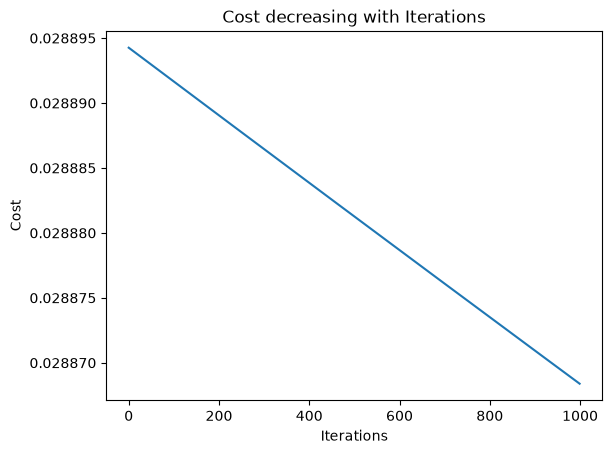

In [336]:
plt.plot(costs)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost decreasing with Iterations")
plt.show()

In [337]:
predictions = (sigmoid >= 0.5).astype(int)
accuracy = np.mean(predictions == y_target) * 100
print(f"Your model is {accuracy:.2f}%")

Your model is 99.30%
